# Country AI Activity Metrics — Data Analysis
### AISI Project | Dataset 3 of 5

This notebook loads, combines, cleans, and explores the **ETO Country AI Activity Metrics** dataset — national-level metrics for AI publications, citations, patents, and private-market investment.

**Nine source files** across three pillars: Publications (3), Patents (3), Companies/Investment (3)

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#0D1117',
    'text.color': '#C9D1D9', 'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E', 'ytick.color': '#8B949E',
    'axes.edgecolor': '#21262D', 'grid.color': '#21262D', 'grid.alpha': 0.6,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 15,
    'figure.dpi': 120,
})

C = {
    'accent': '#58A6FF', 'accent2': '#3FB950', 'accent3': '#D29922',
    'accent4': '#F778BA', 'accent5': '#BC8CFF', 'danger': '#F85149',
    'muted': '#484F58', 'bg': '#0D1117', 'surface': '#161B22',
    'border': '#21262D', 'text': '#C9D1D9', 'text_dim': '#8B949E',
    'cyan': '#39D2C0', 'orange': '#F97316',
}
PILLAR_COLORS = {'Publications': C['accent'], 'Patents': C['accent3'], 'Investment': C['accent2']}

# Known group/aggregate entities (not individual countries)
GROUP_ENTITIES = {
    'ASEAN', 'Africa', 'Asia', 'EU', 'Europe', 'Five Eyes',
    'Global Partnership on Artificial Intelligence', 'NATO',
    'North America and the Caribbean', 'OECD', 'Oceania', 'Quad',
    'Sub-Saharan Africa', 'G7', 'G20', 'MIKTA', 'Latin America'
}

print('Setup complete ✓')

Setup complete ✓


In [2]:
# ── Load all 9 CSV files ──
D = '/Users/shadowclone/Documents/aisi/datasets/Country AI activity/'

pub_articles  = pd.read_csv(f'{D}publications_yearly_articles.csv')
pub_citations = pd.read_csv(f'{D}publications_yearly_citations.csv')
pub_summary   = pd.read_csv(f'{D}publications_summary.csv')
pat_apps      = pd.read_csv(f'{D}patents_yearly_applications.csv')
pat_granted   = pd.read_csv(f'{D}patents_yearly_granted.csv')
pat_summary   = pd.read_csv(f'{D}patents_summary.csv')
comp_disclosed = pd.read_csv(f'{D}companies_yearly_disclosed.csv')
comp_estimated = pd.read_csv(f'{D}companies_yearly_estimated.csv')
comp_summary   = pd.read_csv(f'{D}companies_summary.csv')

tables = [
    ('pub_articles', pub_articles), ('pub_citations', pub_citations), ('pub_summary', pub_summary),
    ('pat_apps', pat_apps), ('pat_granted', pat_granted), ('pat_summary', pat_summary),
    ('comp_disclosed', comp_disclosed), ('comp_estimated', comp_estimated), ('comp_summary', comp_summary),
]
print('Loaded 9 tables:')
for name, df in tables:
    print(f'  {name:20s} → {df.shape[0]:>6,} rows × {df.shape[1]:>2} cols | {df.country.nunique():>3} countries')

Loaded 9 tables:
  pub_articles         →  8,961 rows ×  5 cols | 204 countries
  pub_citations        →  8,642 rows ×  4 cols | 203 countries
  pub_summary          →  1,058 rows ×  4 cols | 203 countries
  pat_apps             →  5,832 rows ×  5 cols |  73 countries
  pat_granted          →  5,124 rows ×  5 cols |  67 countries
  pat_summary          →  1,825 rows ×  4 cols |  73 countries
  comp_disclosed       → 13,556 rows ×  5 cols | 111 countries
  comp_estimated       → 15,339 rows ×  5 cols | 117 countries
  comp_summary         →  2,456 rows ×  4 cols | 117 countries


---
## 2. Individual Table Inspection

### 2.1 Publications

In [3]:
print('Fields:', sorted(pub_articles.field.unique()))
print(f'Years: {pub_articles.year.min()}-{pub_articles.year.max()}')
print(f'Complete years: 2015-2023 | Incomplete: 2024-2025')
print(f'\nCitations table has NO complete flag — will use lagged window per AISI methodology')
print(f'\nArticle stats (All field, complete years, countries only):')
pa_clean = pub_articles[(pub_articles.field=='All') & (pub_articles.complete==True) & 
                         (~pub_articles.country.isin(GROUP_ENTITIES))]
print(pa_clean.num_articles.describe().to_string())
pub_articles.head(3)

Fields: ['AI Safety', 'All', 'Computer Vision', 'Large language models', 'Natural Language Processing', 'Robotics']
Years: 2015-2025
Complete years: 2015-2023 | Incomplete: 2024-2025

Citations table has NO complete flag — will use lagged window per AISI methodology

Article stats (All field, complete years, countries only):
count      1474.000000
mean       1514.292402
std        5935.175710
min           1.000000
25%           9.000000
50%          81.500000
75%         849.000000
max      103672.000000


,country,field,year,num_articles,complete
0,New Zealand,AI Safety,2020,13,True
1,Lebanon,AI Safety,2021,1,True
2,Finland,AI Safety,2017,14,True


### 2.2 Patents

In [4]:
print('Yearly fields (12):', sorted(pat_apps.field.unique()))
print(f'Summary fields (25) — includes technique-level breakdowns')
print(f'\nYears: {pat_apps.year.min()}-{pat_apps.year.max()}')
print(f'Complete years: 2015-2020 | Incomplete: 2021-2025 (significant lag!)')
print(f'\nPatent granted completeness: only {pat_granted.complete.mean():.0%} rows complete')
print(f'\nPatent apps stats (All field, complete, countries only):')
pa_c = pat_apps[(pat_apps.field=='All') & (pat_apps.complete==True) & 
                 (~pat_apps.country.isin(GROUP_ENTITIES))]
print(pa_c.num_patent_applications.describe().to_string())

Yearly fields (12): ['Agriculture', 'All', 'Banking and Finance', 'Business', 'Energy Management', 'Industry and Manufacturing', 'Life Sciences', 'Personal Devices and Computing', 'Physical Sciences and Engineering', 'Security', 'Telecommunications', 'Transportation']
Summary fields (25) — includes technique-level breakdowns

Years: 2015-2025
Complete years: 2015-2020 | Incomplete: 2021-2025 (significant lag!)

Patent granted completeness: only 47% rows complete

Patent apps stats (All field, complete, countries only):
count      321.000000
mean       911.595016
std       5031.308099
min          1.000000
25%          4.000000
50%         12.000000
75%        102.000000
max      66279.000000


### 2.3 Companies / Investment

In [5]:
print(f'Fields: {comp_disclosed.field.nunique()} unique')
print(f'Years: {comp_disclosed.year.min()}-{comp_disclosed.year.max()}')
print(f'Complete: {comp_disclosed.complete.mean():.0%}')
print(f'\nDisclosed vs Estimated investment comparison (All field, 2023):')
d23 = comp_disclosed[(comp_disclosed.field=='All') & (comp_disclosed.year==2023) &
                      (~comp_disclosed.country.isin(GROUP_ENTITIES))]
e23 = comp_estimated[(comp_estimated.field=='All') & (comp_estimated.year==2023) &
                      (~comp_estimated.country.isin(GROUP_ENTITIES))]
merged = d23.merge(e23[['country','estimated_investment']], on='country', how='outer')
merged['ratio'] = merged['estimated_investment'] / merged['disclosed_investment'].replace(0, np.nan)
print(f'  Median estimated/disclosed ratio: {merged.ratio.median():.1f}x')
print(f'  → Estimated values are significantly higher, confirming switch to estimated for AISI')

Fields: 37 unique
Years: 2015-2025
Complete: 91%

Disclosed vs Estimated investment comparison (All field, 2023):
  Median estimated/disclosed ratio: 1.5x
  → Estimated values are significantly higher, confirming switch to estimated for AISI


---
## 3. Combining Into Master Datasets
We create three pillar-specific masters, then a unified country-level master.

In [6]:
# ── 3.1 Publications master: merge articles + citations by country/field/year ──
pub_master = pub_articles.merge(
    pub_citations, on=['country', 'field', 'year'], how='outer'
)
pub_master['pillar'] = 'publications'
pub_master['is_group'] = pub_master.country.isin(GROUP_ENTITIES)
print(f'Publications master: {pub_master.shape}')
print(f'  Group entities: {pub_master.is_group.sum()} rows')
print(f'  Countries: {pub_master[~pub_master.is_group].country.nunique()}')

Publications master: (8983, 8)
  Group entities: 792 rows
  Countries: 192


In [7]:
# ── 3.2 Patents master: merge applications + granted by country/field/year ──
pat_master = pat_apps.merge(
    pat_granted, on=['country', 'field', 'year'], how='outer', suffixes=('_apps', '_granted')
)
# Reconcile complete flags
pat_master['complete'] = pat_master['complete_apps'].fillna(False) & pat_master['complete_granted'].fillna(False)
pat_master = pat_master.drop(columns=['complete_apps', 'complete_granted'])
pat_master['pillar'] = 'patents'
pat_master['is_group'] = pat_master.country.isin(GROUP_ENTITIES)
print(f'Patents master: {pat_master.shape}')
print(f'  Countries: {pat_master[~pat_master.is_group].country.nunique()}')

Patents master: (5832, 8)
  Countries: 73


In [8]:
# ── 3.3 Investment master: merge disclosed + estimated by country/field/year ──
inv_master = comp_disclosed.merge(
    comp_estimated, on=['country', 'field', 'year'], how='outer', suffixes=('_disc', '_est')
)
inv_master['complete'] = inv_master['complete_disc'].fillna(False) | inv_master['complete_est'].fillna(False)
inv_master = inv_master.drop(columns=['complete_disc', 'complete_est'])
inv_master['pillar'] = 'investment'
inv_master['is_group'] = inv_master.country.isin(GROUP_ENTITIES)
print(f'Investment master: {inv_master.shape}')
print(f'  Countries: {inv_master[~inv_master.is_group].country.nunique()}')

Investment master: (15339, 8)
  Countries: 117


In [9]:
# ── 3.4 Unified country-level summary (All field, countries only) ──
# Publications: latest 3 complete years
pub_3yr = pub_articles[
    (pub_articles.field == 'All') & (pub_articles.complete == True) &
    (~pub_articles.country.isin(GROUP_ENTITIES))
].copy()
latest_pub_years = sorted(pub_3yr.year.unique())[-3:]
pub_3yr = pub_3yr[pub_3yr.year.isin(latest_pub_years)]
pub_agg = pub_3yr.groupby('country').agg(
    avg_annual_articles=('num_articles', 'mean')
).reset_index()

# Citations: lagged window (2+ years back from latest)
cit_data = pub_citations[
    (pub_citations.field == 'All') & (~pub_citations.country.isin(GROUP_ENTITIES))
].copy()
max_cit_year = cit_data.year.max()
cit_window = cit_data[(cit_data.year >= max_cit_year - 4) & (cit_data.year <= max_cit_year - 2)]
# Merge with articles for per-article citations
cit_merged = cit_window.merge(
    pub_articles[pub_articles.field=='All'][['country','year','num_articles']],
    on=['country','year'], how='left'
)
cit_merged['cit_per_article'] = cit_merged.num_citations / cit_merged.num_articles.replace(0, np.nan)
cit_agg = cit_merged.groupby('country').agg(
    avg_cit_per_article=('cit_per_article', 'mean')
).reset_index()

# Patents: All field, complete years
pat_c = pat_apps[
    (pat_apps.field == 'All') & (pat_apps.complete == True) &
    (~pat_apps.country.isin(GROUP_ENTITIES))
].copy()
pat_agg = pat_c.groupby('country').agg(
    total_patent_apps=('num_patent_applications', 'sum')
).reset_index()

# Patent field diversity
pat_div = pat_apps[
    (pat_apps.field != 'All') & (pat_apps.complete == True) &
    (~pat_apps.country.isin(GROUP_ENTITIES)) &
    (pat_apps.num_patent_applications > 0)
]
pat_diversity = pat_div.groupby('country')['field'].nunique().reset_index(name='patent_field_diversity')

# Investment: estimated, All field, complete
inv_c = comp_estimated[
    (comp_estimated.field == 'All') & (comp_estimated.complete == True) &
    (~comp_estimated.country.isin(GROUP_ENTITIES))
].copy()
inv_agg = inv_c.groupby('country').agg(
    total_estimated_investment=('estimated_investment', 'sum')
).reset_index()

# Merge all
country_master = pub_agg
for df in [cit_agg, pat_agg, pat_diversity, inv_agg]:
    country_master = country_master.merge(df, on='country', how='outer')

# Add data availability flags
country_master['has_publications'] = country_master['avg_annual_articles'].notna()
country_master['has_citations'] = country_master['avg_cit_per_article'].notna()
country_master['has_patents'] = country_master['total_patent_apps'].notna()
country_master['has_investment'] = country_master['total_estimated_investment'].notna()

print(f'✅ Country master: {country_master.shape}')
print(f'\nData availability:')
for col in ['has_publications', 'has_citations', 'has_patents', 'has_investment']:
    print(f'  {col:25s}: {country_master[col].sum():>3} / {len(country_master)}')
country_master.sort_values('avg_annual_articles', ascending=False).head(10)

✅ Country master: (189, 10)

Data availability:
  has_publications         : 185 / 189
  has_citations            : 183 / 189
  has_patents              :  71 / 189
  has_investment           : 117 / 189


,country,avg_annual_articles,avg_cit_per_article,total_patent_apps,patent_field_diversity,total_estimated_investment,has_publications,has_citations,has_patents,has_investment
33,China (mainland),85666.333333,17.463926,164582.0,11.0,96554.0,True,True,True,True
179,United States,48214.666667,23.072854,63326.0,11.0,849399.0,True,True,True,True
73,India,34775.666667,9.770055,827.0,11.0,45799.0,True,True,True,True
178,United Kingdom,14885.333333,25.526073,1828.0,11.0,40938.0,True,True,True,True
62,Germany,13144.000000,19.559277,3316.0,11.0,31736.0,True,True,True,True
82,Japan,10324.333333,9.575710,16570.0,11.0,10747.0,True,True,True,True
152,South Korea,9126.666667,20.099960,23074.0,11.0,16484.0,True,True,True,True
30,Canada,8480.000000,21.371817,3267.0,11.0,43002.0,True,True,True,True
80,Italy,8107.666667,17.118540,229.0,11.0,1651.0,True,True,True,True
58,France,7605.666667,16.113925,886.0,11.0,26683.0,True,True,True,True


---
## 4. Data Cleaning & Quality Assessment

In [10]:
# ── 4.1 Group entities identified and separated ──
print(f'Group/aggregate entities excluded from country master:')
groups_found = set()
for df in [pub_articles, pat_apps, comp_estimated]:
    groups_found.update(df[df.country.isin(GROUP_ENTITIES)].country.unique())
for g in sorted(groups_found):
    print(f'  {g}')
print(f'\nTotal: {len(groups_found)} group entities excluded')

Group/aggregate entities excluded from country master:
  ASEAN
  Africa
  Asia
  EU
  Europe
  Five Eyes
  Global Partnership on Artificial Intelligence
  NATO
  North America and the Caribbean
  OECD
  Oceania
  Quad

Total: 12 group entities excluded


In [11]:
# ── 4.2 Country name consistency across pillars ──
pub_c = set(pub_articles[~pub_articles.country.isin(GROUP_ENTITIES)].country.unique())
pat_c = set(pat_apps[~pat_apps.country.isin(GROUP_ENTITIES)].country.unique())
inv_c_set = set(comp_estimated[~comp_estimated.country.isin(GROUP_ENTITIES)].country.unique())

all_countries = pub_c | pat_c | inv_c_set
in_all = pub_c & pat_c & inv_c_set
pub_only = pub_c - pat_c - inv_c_set
pat_only = pat_c - pub_c - inv_c_set

print(f'Countries across pillars:')
print(f'  Publications only: {len(pub_only)} (many small nations with papers but no patents/investment)')
print(f'  Patents only: {len(pat_only)}')
print(f'  In all 3 pillars: {len(in_all)}')
print(f'  Total unique: {len(all_countries)}')

# Check for naming mismatches
china_variants = [c for c in all_countries if 'china' in c.lower() or 'chinese' in c.lower()]
print(f'\nChina variants: {china_variants}')

Countries across pillars:
  Publications only: 72 (many small nations with papers but no patents/investment)
  Patents only: 4
  In all 3 pillars: 66
  Total unique: 196

China variants: ['China (mainland)']


In [12]:
# ── 4.3 Skewness check ──
print('Distribution skewness (justifying log transforms for AISI):')
for col in ['avg_annual_articles', 'total_patent_apps', 'total_estimated_investment']:
    vals = country_master[col].dropna()
    print(f'  {col:35s}: skew={vals.skew():.1f}, kurtosis={vals.kurtosis():.1f}')
    print(f'    top1 = {vals.max():,.0f}, median = {vals.median():,.0f}, ratio = {vals.max()/vals.median():,.0f}x')

Distribution skewness (justifying log transforms for AISI):
  avg_annual_articles                : skew=8.3, kurtosis=78.4
    top1 = 85,666, median = 76, ratio = 1,127x
  total_patent_apps                  : skew=6.9, kurtosis=51.3
    top1 = 164,582, median = 33, ratio = 4,987x
  total_estimated_investment         : skew=10.4, kurtosis=111.0
    top1 = 849,399, median = 126, ratio = 6,741x


---
## 5. Save Combined Datasets

In [14]:
OUT = '/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/'

# Save pillar masters
pub_master.to_csv(f'{OUT}country_ai_publications_master.csv', index=False)
pat_master.to_csv(f'{OUT}country_ai_patents_master.csv', index=False)
inv_master.to_csv(f'{OUT}country_ai_investment_master.csv', index=False)

# Save unified country summary
country_master.to_csv(f'{OUT}country_ai_unified_master.csv', index=False)

print('✅ Saved 4 files:')
for f, df in [('country_ai_publications_master.csv', pub_master),
              ('country_ai_patents_master.csv', pat_master),
              ('country_ai_investment_master.csv', inv_master),
              ('country_ai_unified_master.csv', country_master)]:
    print(f'  {f:45s} → {df.shape[0]:>6,} rows × {df.shape[1]:>2} cols')

✅ Saved 4 files:
  country_ai_publications_master.csv            →  8,983 rows ×  8 cols
  country_ai_patents_master.csv                 →  5,832 rows ×  8 cols
  country_ai_investment_master.csv              → 15,339 rows ×  8 cols
  country_ai_unified_master.csv                 →    189 rows × 10 cols


---
## 6. Exploratory Analysis & Visualizations

### 6.1 Dataset Overview

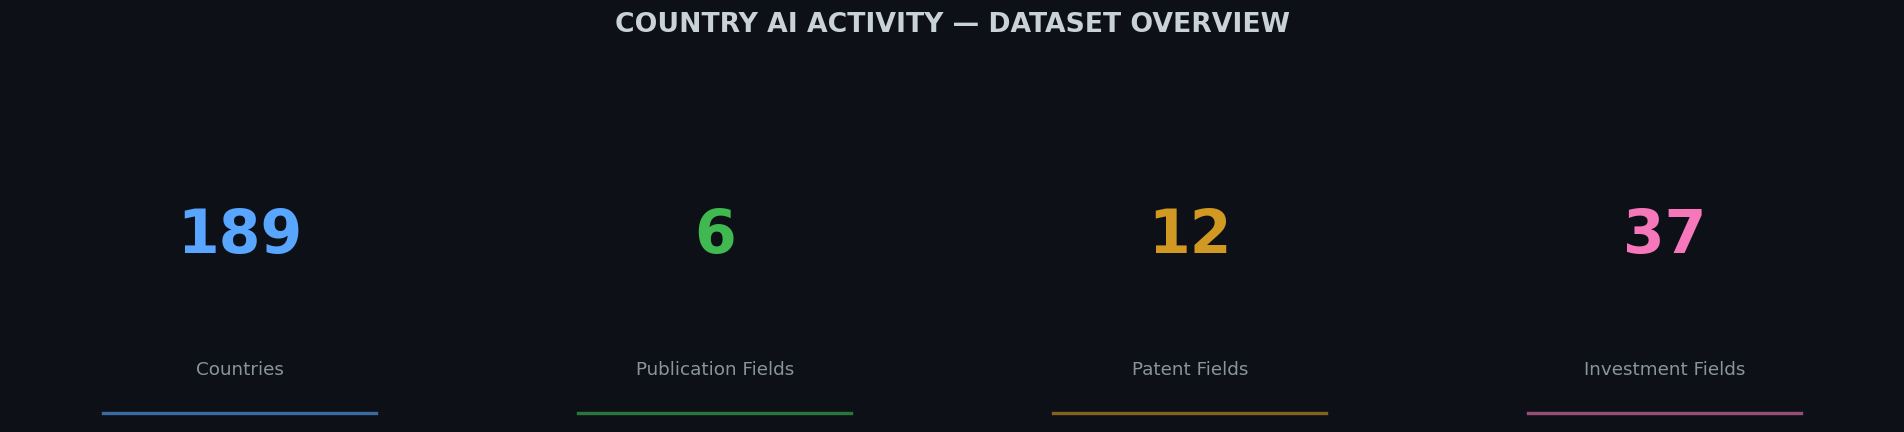

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle('COUNTRY AI ACTIVITY — DATASET OVERVIEW',
             fontsize=16, fontweight='bold', color=C['text'], y=1.02)
stats = [
    ('Countries', f'{len(country_master)}', C['accent']),
    ('Publication Fields', f'{pub_articles.field.nunique()}', C['accent2']),
    ('Patent Fields', f'{pat_apps.field.nunique()}', C['accent3']),
    ('Investment Fields', f'{comp_estimated.field.nunique()}', C['accent4']),
]
for ax, (label, value, color) in zip(axes, stats):
    ax.text(0.5, 0.55, value, fontsize=36, fontweight='bold',
            color=color, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 0.15, label, fontsize=11, color=C['text_dim'],
            ha='center', va='center', transform=ax.transAxes)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.axhline(y=0.02, xmin=0.2, xmax=0.8, color=color, linewidth=2, alpha=0.6)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_01_overview.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.2 Top 15 Countries by AI Publications (Latest 3 Complete Years)

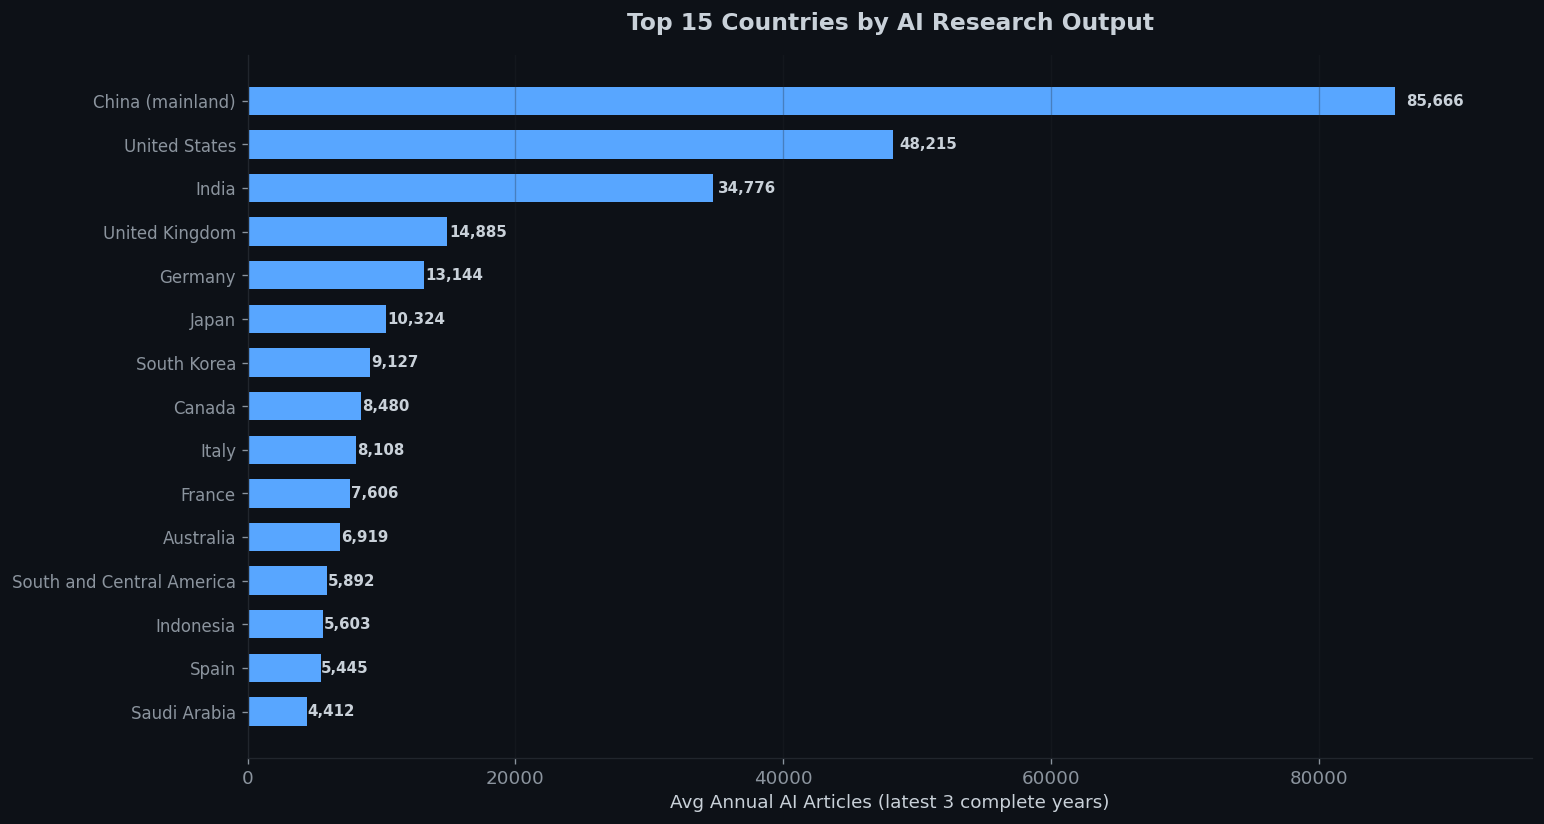

In [17]:
top15 = country_master.sort_values('avg_annual_articles', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(range(len(top15)), top15['avg_annual_articles'], color=C['accent'], height=0.65)
ax.set_yticks(range(len(top15))); ax.set_yticklabels(top15['country'], fontsize=10)
ax.invert_yaxis()
for i, val in enumerate(top15['avg_annual_articles']):
    ax.text(val + val*0.01, i, f'{val:,.0f}', va='center', fontsize=9, fontweight='bold', color=C['text'])
ax.set_xlabel('Avg Annual AI Articles (latest 3 complete years)')
ax.set_title('Top 15 Countries by AI Research Output', pad=15)
ax.grid(axis='x', alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim(0, top15['avg_annual_articles'].max() * 1.12)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_02_top_pubs.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.3 Publication Growth Trends — Top 6 Countries

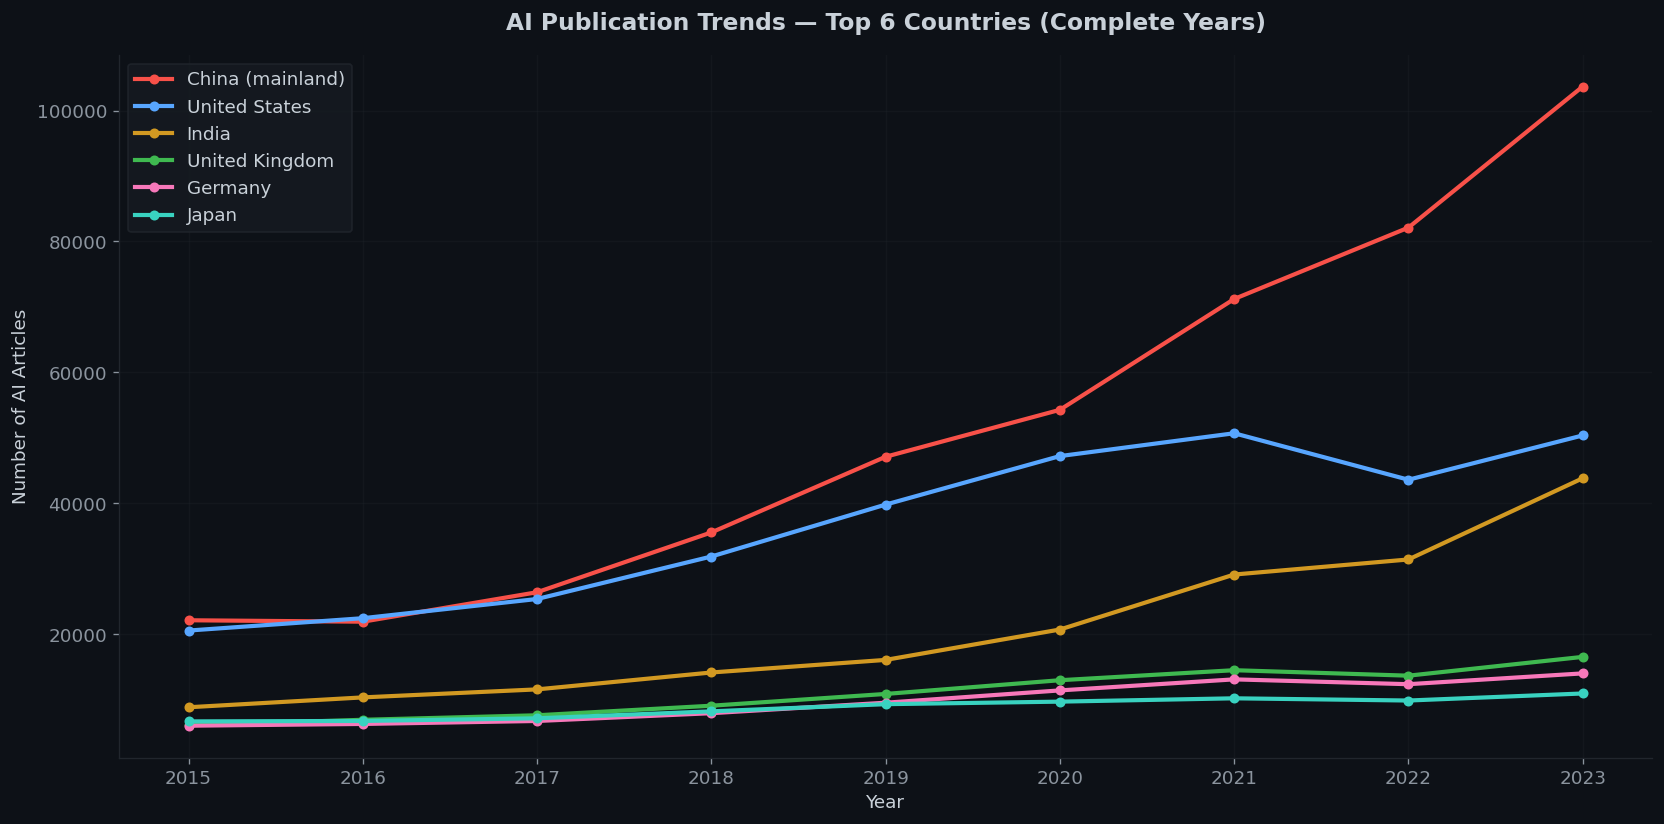

In [18]:
top6 = country_master.sort_values('avg_annual_articles', ascending=False).head(6).country.tolist()
trend_data = pub_articles[
    (pub_articles.field == 'All') & (pub_articles.complete == True) &
    (pub_articles.country.isin(top6))
].copy()

palette = [C['danger'], C['accent'], C['accent3'], C['accent2'], C['accent4'], C['cyan']]

fig, ax = plt.subplots(figsize=(14, 7))
for i, country in enumerate(top6):
    cdata = trend_data[trend_data.country == country].sort_values('year')
    ax.plot(cdata.year, cdata.num_articles, color=palette[i],
            linewidth=2.5, marker='o', markersize=5, label=country)
ax.set_title('AI Publication Trends — Top 6 Countries (Complete Years)', pad=15)
ax.set_xlabel('Year'); ax.set_ylabel('Number of AI Articles')
ax.legend(frameon=True, facecolor=C['surface'], edgecolor=C['border'])
ax.grid(True, alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_03_pub_trends.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.4 Citation Impact — Quality vs Quantity

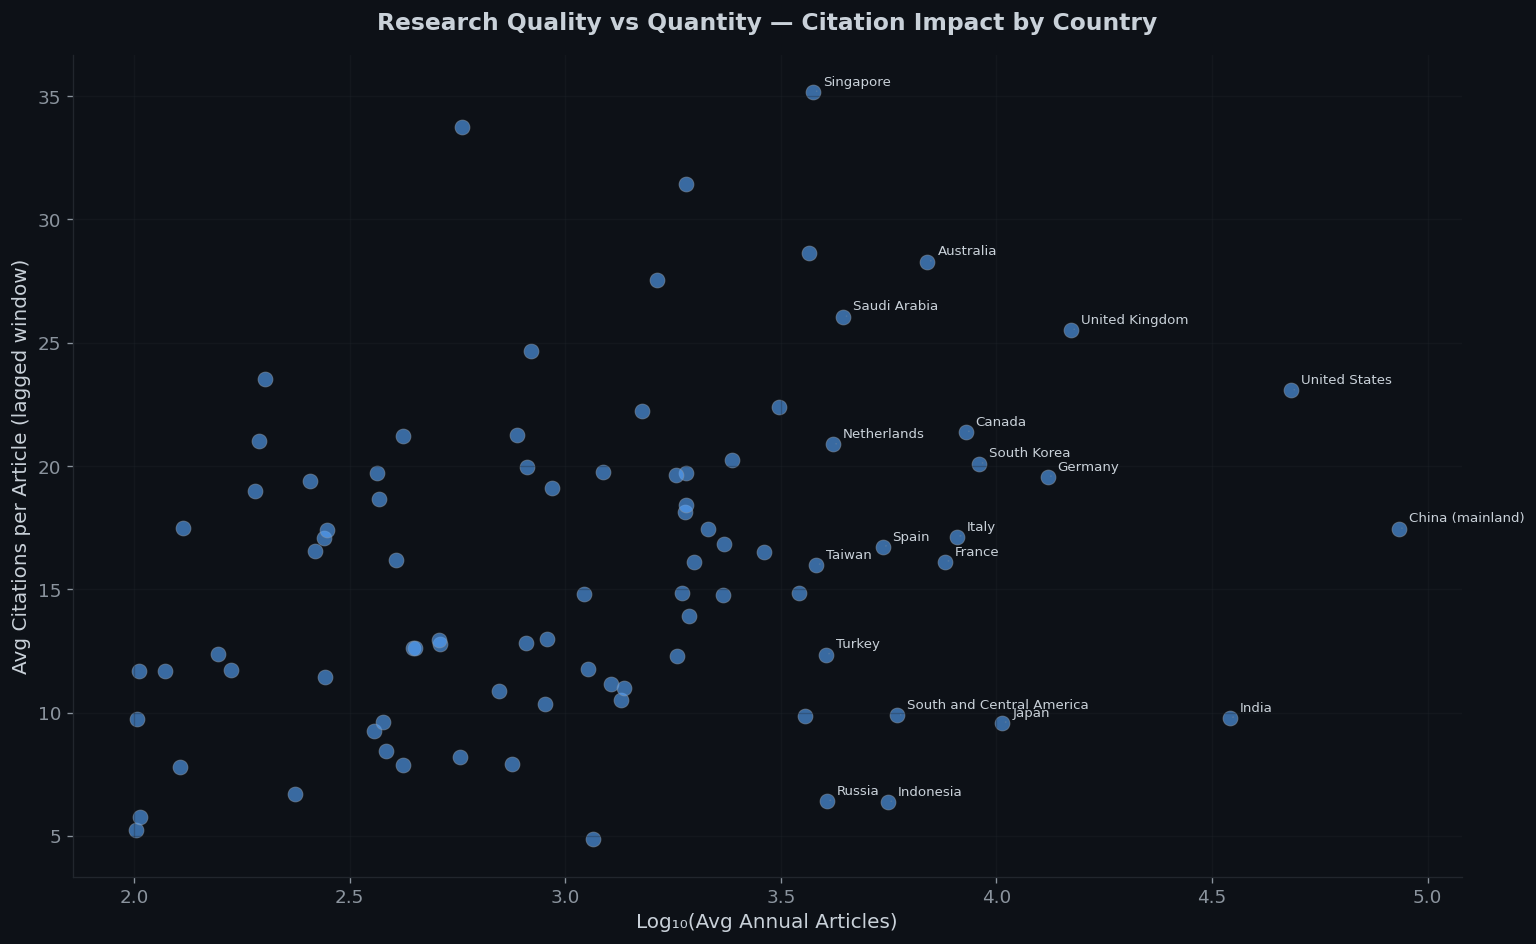

In [19]:
ciq = country_master.dropna(subset=['avg_annual_articles', 'avg_cit_per_article']).copy()
ciq = ciq[ciq.avg_annual_articles > 100]  # filter tiny countries

fig, ax = plt.subplots(figsize=(13, 8))
scatter = ax.scatter(
    np.log10(ciq['avg_annual_articles']),
    ciq['avg_cit_per_article'],
    s=80, c=C['accent'], alpha=0.6, edgecolors=C['text_dim'], linewidths=0.5
)
# Label top countries
for _, row in ciq.nlargest(20, 'avg_annual_articles').iterrows():
    ax.annotate(row.country, (np.log10(row.avg_annual_articles), row.avg_cit_per_article),
        xytext=(6, 4), textcoords='offset points', fontsize=8, color=C['text'],
        arrowprops=dict(arrowstyle='-', color=C['text_dim'], alpha=0.3))
ax.set_xlabel('Log₁₀(Avg Annual Articles)', fontsize=12)
ax.set_ylabel('Avg Citations per Article (lagged window)', fontsize=12)
ax.set_title('Research Quality vs Quantity — Citation Impact by Country', pad=15)
ax.grid(True, alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_04_cit_impact.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.5 Patent Landscape — Top 15 Countries

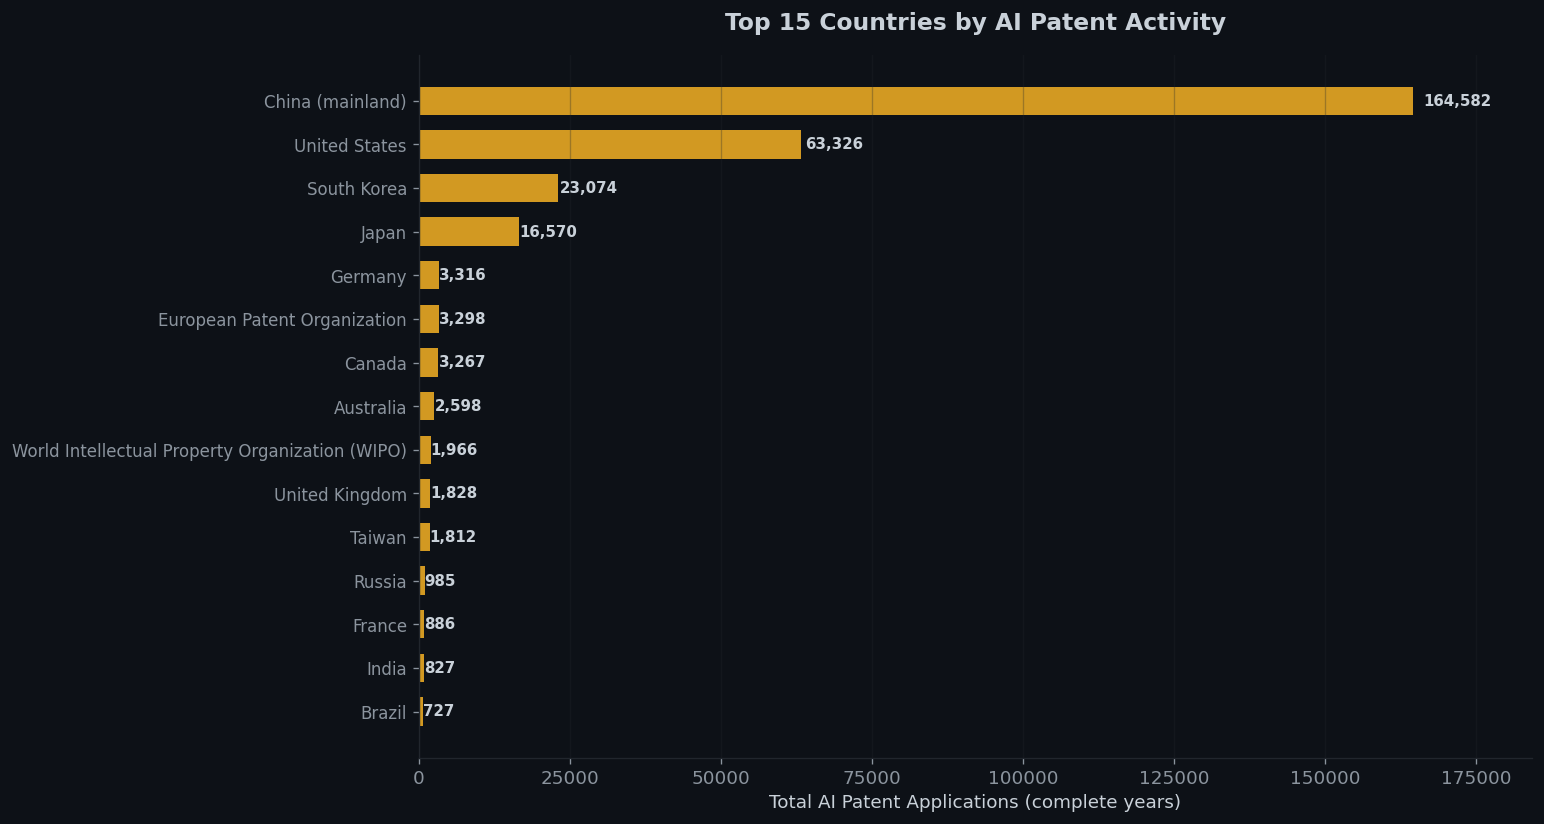

In [20]:
pat_top = country_master.dropna(subset=['total_patent_apps']).sort_values('total_patent_apps', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(range(len(pat_top)), pat_top['total_patent_apps'], color=C['accent3'], height=0.65)
ax.set_yticks(range(len(pat_top))); ax.set_yticklabels(pat_top['country'], fontsize=10)
ax.invert_yaxis()
for i, val in enumerate(pat_top['total_patent_apps']):
    ax.text(val + val*0.01, i, f'{val:,.0f}', va='center', fontsize=9, fontweight='bold', color=C['text'])
ax.set_xlabel('Total AI Patent Applications (complete years)')
ax.set_title('Top 15 Countries by AI Patent Activity', pad=15)
ax.grid(axis='x', alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim(0, pat_top['total_patent_apps'].max() * 1.12)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_05_patents.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.6 AI Investment — Top 15 Countries (Estimated)

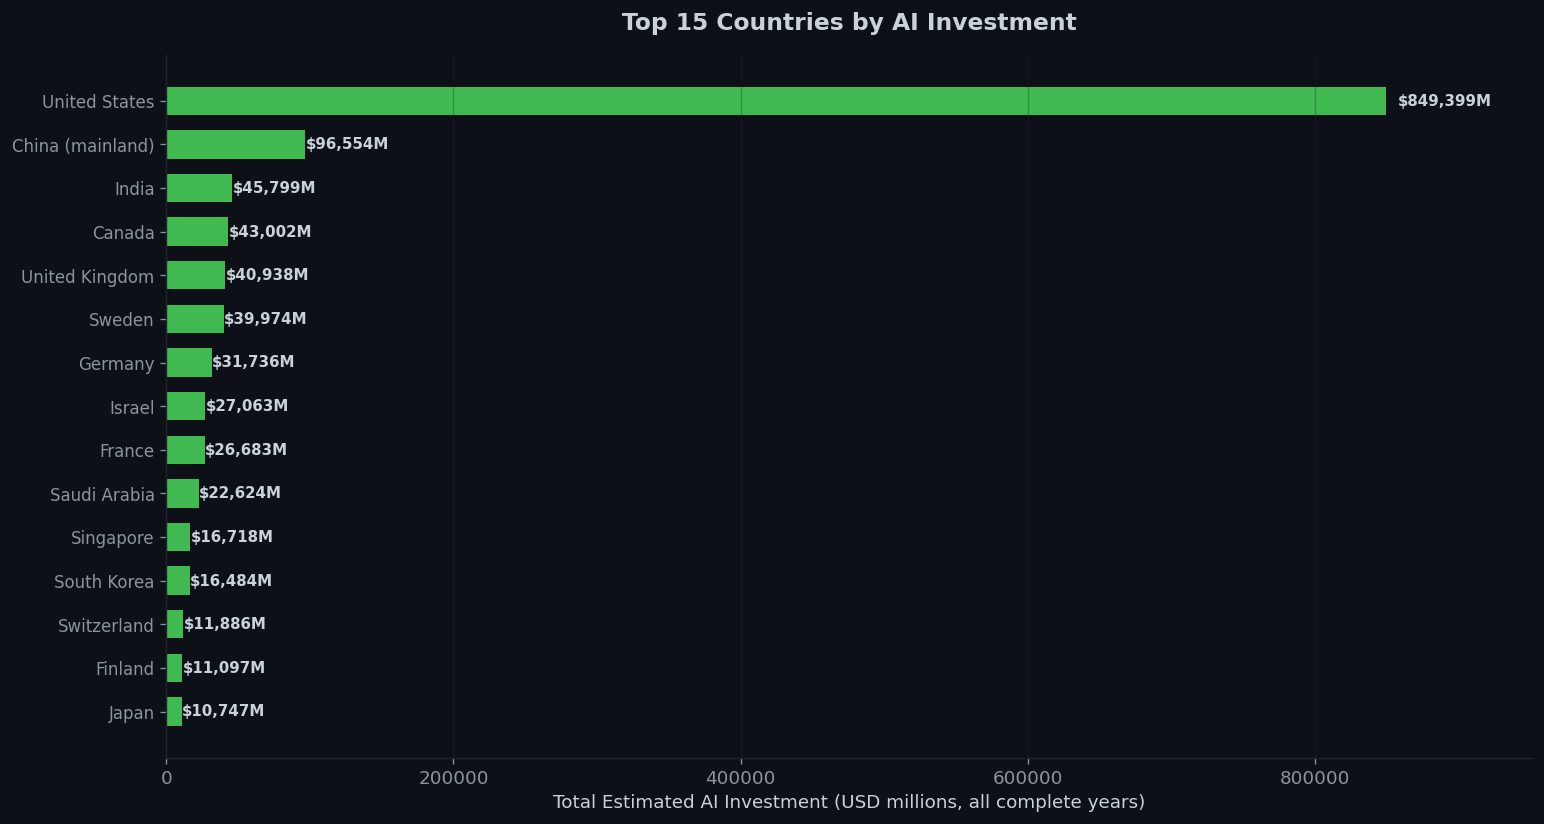

In [21]:
inv_top = country_master.dropna(subset=['total_estimated_investment']).sort_values('total_estimated_investment', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(range(len(inv_top)), inv_top['total_estimated_investment'], color=C['accent2'], height=0.65)
ax.set_yticks(range(len(inv_top))); ax.set_yticklabels(inv_top['country'], fontsize=10)
ax.invert_yaxis()
for i, val in enumerate(inv_top['total_estimated_investment']):
    ax.text(val + val*0.01, i, f'${val:,.0f}M', va='center', fontsize=9, fontweight='bold', color=C['text'])
ax.set_xlabel('Total Estimated AI Investment (USD millions, all complete years)')
ax.set_title('Top 15 Countries by AI Investment', pad=15)
ax.grid(axis='x', alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim(0, inv_top['total_estimated_investment'].max() * 1.12)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_06_investment.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.7 Three-Pillar Radar — Top 10 Countries
Comparing research output, patent activity, and investment across the top countries.

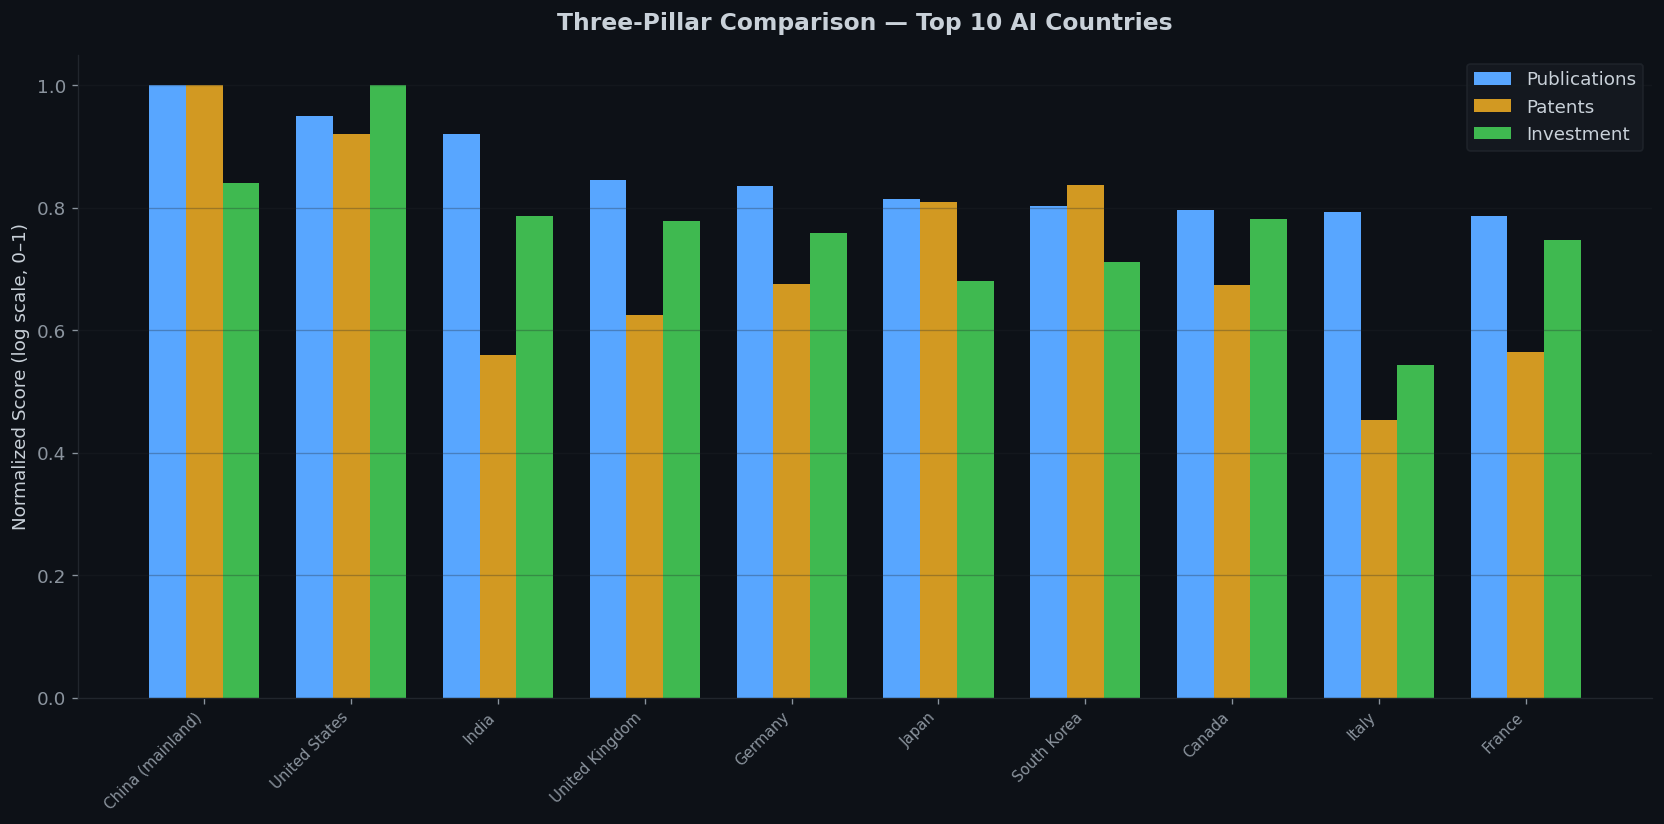

In [22]:
# Normalize each metric to 0-1 for comparison
radar_data = country_master.dropna(subset=['avg_annual_articles', 'total_patent_apps', 'total_estimated_investment']).copy()
for col in ['avg_annual_articles', 'total_patent_apps', 'total_estimated_investment']:
    radar_data[f'{col}_norm'] = np.log1p(radar_data[col]) / np.log1p(radar_data[col]).max()

top10 = radar_data.sort_values('avg_annual_articles', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(top10))
w = 0.25

ax.bar(x - w, top10['avg_annual_articles_norm'], w, color=C['accent'], label='Publications')
ax.bar(x,     top10['total_patent_apps_norm'], w, color=C['accent3'], label='Patents')
ax.bar(x + w, top10['total_estimated_investment_norm'], w, color=C['accent2'], label='Investment')

ax.set_xticks(x); ax.set_xticklabels(top10['country'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalized Score (log scale, 0–1)')
ax.set_title('Three-Pillar Comparison — Top 10 AI Countries', pad=15)
ax.legend(frameon=True, facecolor=C['surface'], edgecolor=C['border'])
ax.grid(axis='y', alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_07_three_pillar.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.8 Investment vs Research Output — Scatter

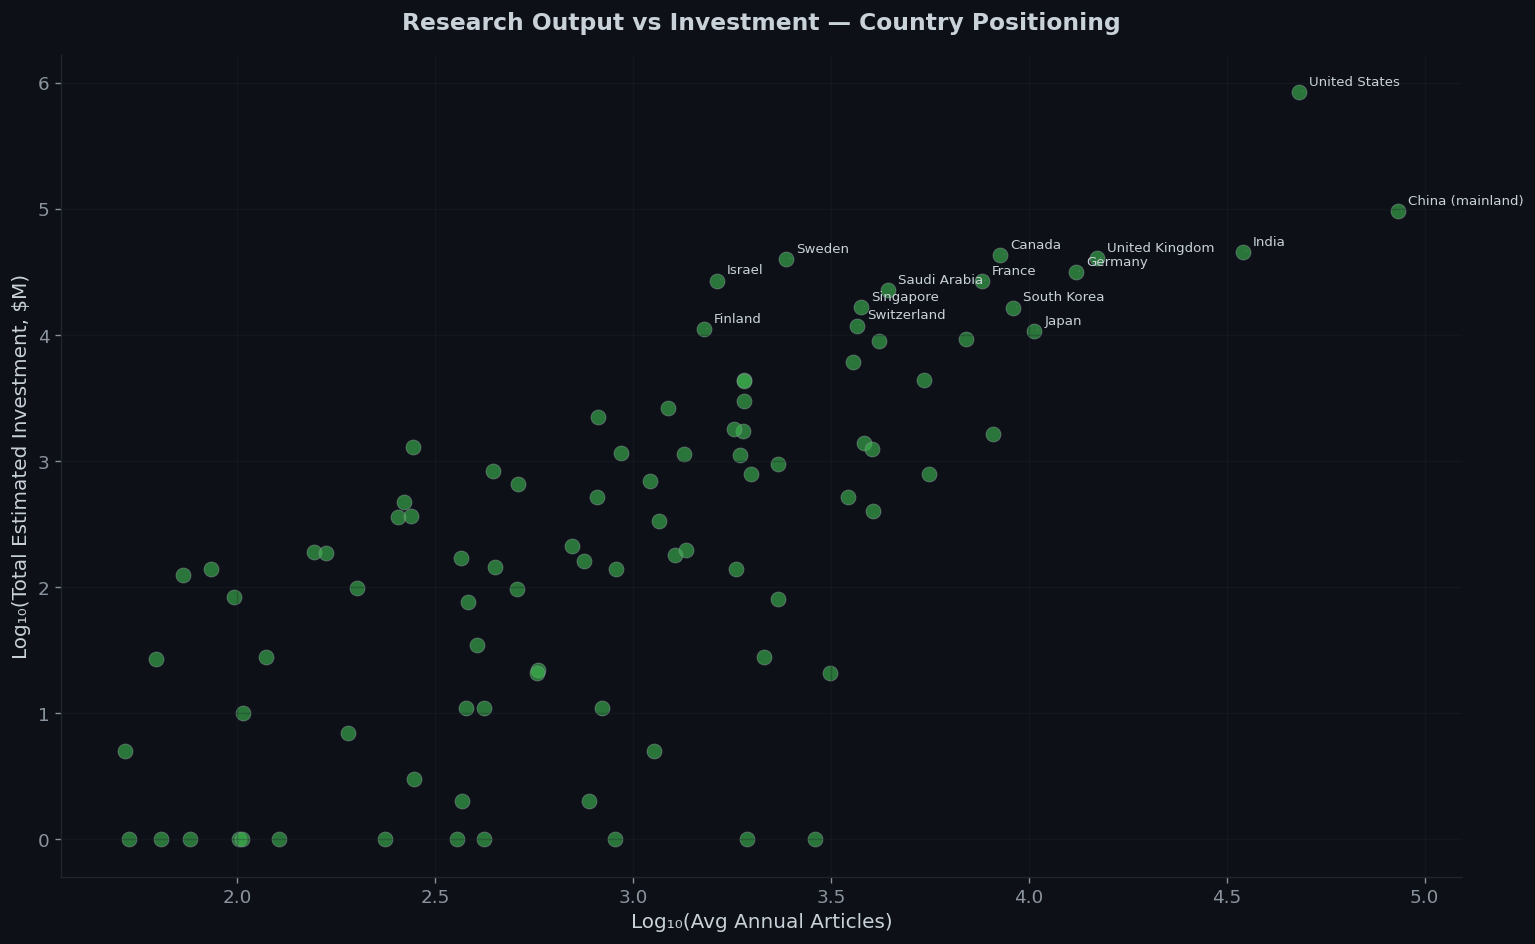

In [23]:
both = country_master.dropna(subset=['avg_annual_articles', 'total_estimated_investment']).copy()
both = both[both.avg_annual_articles > 50]

fig, ax = plt.subplots(figsize=(13, 8))
ax.scatter(np.log10(both['avg_annual_articles']), np.log10(both['total_estimated_investment'].clip(lower=1)),
    s=80, c=C['accent2'], alpha=0.6, edgecolors=C['text_dim'], linewidths=0.5)
for _, row in both.nlargest(15, 'total_estimated_investment').iterrows():
    ax.annotate(row.country,
        (np.log10(row.avg_annual_articles), np.log10(max(row.total_estimated_investment, 1))),
        xytext=(6, 4), textcoords='offset points', fontsize=8, color=C['text'],
        arrowprops=dict(arrowstyle='-', color=C['text_dim'], alpha=0.3))
ax.set_xlabel('Log₁₀(Avg Annual Articles)', fontsize=12)
ax.set_ylabel('Log₁₀(Total Estimated Investment, $M)', fontsize=12)
ax.set_title('Research Output vs Investment — Country Positioning', pad=15)
ax.grid(True, alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_08_invest_vs_research.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.9 Data Coverage Heatmap — Which Countries Have What?

Data coverage distribution:
coverage_score
1     6
2    64
3    54
4    65


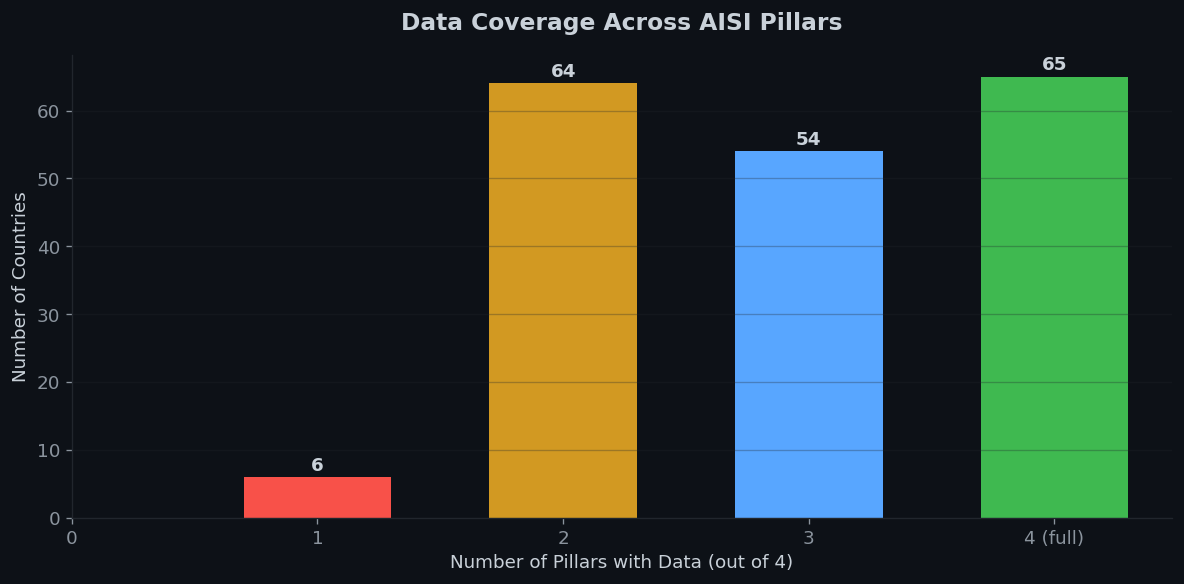

In [24]:
coverage = country_master[['country','has_publications','has_citations','has_patents','has_investment']].copy()
coverage['coverage_score'] = coverage[['has_publications','has_citations','has_patents','has_investment']].sum(axis=1)

print('Data coverage distribution:')
print(coverage['coverage_score'].value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(10, 5))
cov_counts = coverage['coverage_score'].value_counts().sort_index()
bars = ax.bar(cov_counts.index, cov_counts.values, 
              color=[C['danger'], C['accent3'], C['accent'], C['accent2'], C['cyan']],
              edgecolor='none', width=0.6)
for bar, val in zip(bars, cov_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=11, fontweight='bold', color=C['text'])
ax.set_xlabel('Number of Pillars with Data (out of 4)')
ax.set_ylabel('Number of Countries')
ax.set_title('Data Coverage Across AISI Pillars', pad=15)
ax.set_xticks([0,1,2,3,4]); ax.set_xticklabels(['0','1','2','3','4 (full)'])
ax.grid(axis='y', alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_09_coverage.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.10 Publication Subfield Breakdown — Top 10 Countries

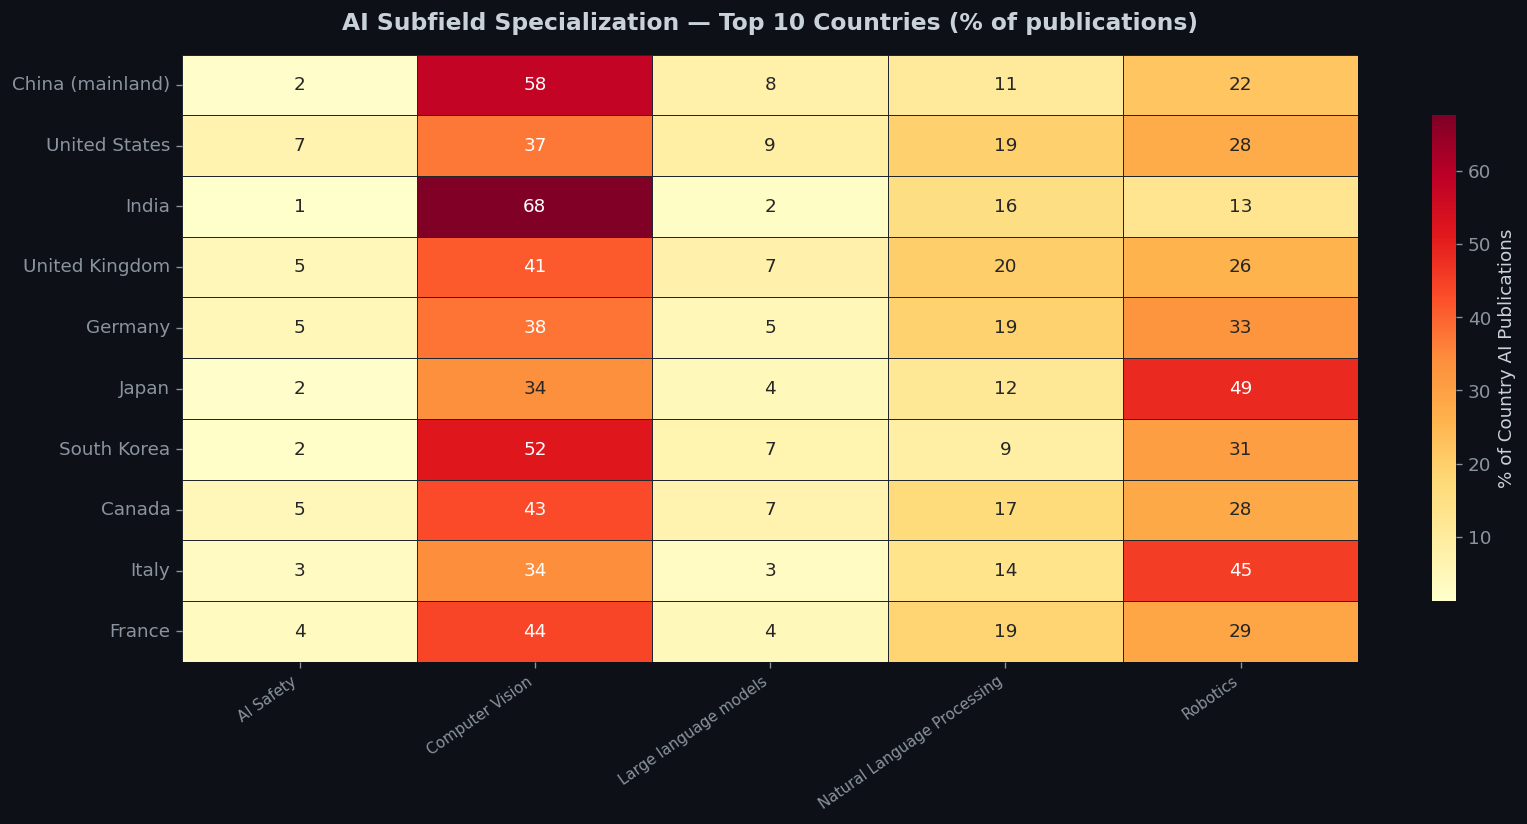

In [25]:
# Subfield analysis for top 10 countries
subfields = pub_articles[
    (pub_articles.field != 'All') & (pub_articles.complete == True) &
    (~pub_articles.country.isin(GROUP_ENTITIES))
].copy()
top10_countries = country_master.sort_values('avg_annual_articles', ascending=False).head(10).country.tolist()
sub_top = subfields[subfields.country.isin(top10_countries)]

sub_pivot = sub_top.pivot_table(index='country', columns='field', values='num_articles', aggfunc='sum', fill_value=0)
sub_pivot = sub_pivot.loc[top10_countries]  # maintain order

# Normalize per country
sub_norm = sub_pivot.div(sub_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(sub_norm, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, linecolor=C['border'],
    cbar_kws={'label': '% of Country AI Publications', 'shrink': 0.8}, ax=ax)
ax.set_title('AI Subfield Specialization — Top 10 Countries (% of publications)', pad=15)
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_viz_10_subfields.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

---
## 7. AISI Pipeline Preview

In [26]:
# Preview of key metrics that feed into AISI dimensions
aisi_preview = country_master.sort_values('avg_annual_articles', ascending=False).head(20).copy()
display_cols = ['country', 'avg_annual_articles', 'avg_cit_per_article', 
                'total_patent_apps', 'patent_field_diversity', 'total_estimated_investment',
                'has_publications', 'has_citations', 'has_patents', 'has_investment']
print('AISI Country AI Activity — Metrics Preview (Top 20)')
print('=' * 100)
print(aisi_preview[display_cols].to_string(index=False, float_format='%.1f'))

AISI Country AI Activity — Metrics Preview (Top 20)
                  country  avg_annual_articles  avg_cit_per_article  total_patent_apps  patent_field_diversity  total_estimated_investment  has_publications  has_citations  has_patents  has_investment
         China (mainland)              85666.3                 17.5           164582.0                    11.0                     96554.0              True           True         True            True
            United States              48214.7                 23.1            63326.0                    11.0                    849399.0              True           True         True            True
                    India              34775.7                  9.8              827.0                    11.0                     45799.0              True           True         True            True
           United Kingdom              14885.3                 25.5             1828.0                    11.0                     40938.0      

---
## Done ✓

**Outputs saved:**
- `country_ai_publications_master.csv` — Publications pillar (articles + citations)
- `country_ai_patents_master.csv` — Patents pillar (applications + granted)
- `country_ai_investment_master.csv` — Investment pillar (disclosed + estimated)
- `country_ai_unified_master.csv` — Unified country-level summary with AISI-ready metrics
- 10 visualization PNGs

**Key findings:**
1. **China dominates publication volume** but the US and smaller nations like Switzerland show higher citation impact
2. **Patent data has massive lag** — only complete through 2020, limiting recent trend analysis
3. **Investment is extremely concentrated** — US captures the vast majority of global AI investment
4. **66 countries have data across all 3 pillars**, while 138+ countries have only publications
5. **Log transformation is essential** — publication and investment distributions have skewness > 5
6. **12 group entities** (OECD, NATO, EU, etc.) identified and excluded from country-level analysis

**Next:** Private-Sector AI Indicators (PARAT)